# 03 · Signal Construction

## Economic rationale

The composite score formalises the reasoning a trader would do by hand:

```
score = z × cal × conf × cons × Δ_net
```

Each multiplier gates the signal on one economic condition:

| Multiplier | Question | Zero means |
|------------|----------|------------|
| `z` | How large is the GP deviation? | No deviation |
| `cal` | Is the option free of event risk? | Earnings / FOMC window |
| `conf` | Is the GP reliable here? | Illiquid region |
| `cons` | Do GP and SVI agree? | Conflicting signals |
| `Δ_net` | Does the signal clear bid-ask? | Not tradable |

Only options passing all five gates generate a non-zero score.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

from gpvol.surface.gp_model import GPSurface
from gpvol.surface.svi_model import calibrate_svi, svi_vol
from gpvol.signal.scoring import score_surface

surface = pd.read_parquet("../data/surface_clean.parquet")

gp = GPSurface(n_restarts_optimizer=3, random_state=0).fit(surface)

# Calibrate SVI for each expiry
svi_by_expiry = {}
for expiry, group in surface.groupby('expiry'):
    T = float(group['T'].iloc[0])
    if len(group) < 5: continue
    svi_by_expiry[expiry] = (T, calibrate_svi(
        group['log_moneyness'].values, group['iv'].values, T,
        n_restarts=15, random_state=0))


## 1 · Compute GP and SVI predictions for every contract

In [2]:
k = surface['log_moneyness'].values
T = surface['T'].values

mu_gp, sigma_gp = gp.predict(k, T)

mu_svi = np.full(len(surface), np.nan)
for i, (expiry, row) in enumerate(surface.iterrows()):
    if row['expiry'] in svi_by_expiry:
        T_sl, params = svi_by_expiry[row['expiry']]
        mu_svi[i] = svi_vol(row['log_moneyness'], T_sl, params)

print(f"GP predictions:  μ ∈ [{mu_gp.min():.3f}, {mu_gp.max():.3f}]")
print(f"GP uncertainty:  σ ∈ [{sigma_gp.min():.4f}, {sigma_gp.max():.4f}]")


GP predictions:  μ ∈ [0.087, 0.552]
GP uncertainty:  σ ∈ [0.0128, 0.0157]


## 2 · Event calendar (FOMC + earnings)

In [3]:
import yfinance as yf

# FOMC dates (manually maintained; announced months in advance)
FOMC_2024 = pd.to_datetime([
    "2024-01-31", "2024-03-20", "2024-05-01", "2024-06-12",
    "2024-07-31", "2024-09-18", "2024-11-07", "2024-12-18",
])

# SPY tracks S&P 500 — no single earnings date, but use SPX member dates
# For a single-name, fetch from yfinance:
# ticker = yf.Ticker("AAPL")
# earnings_date = pd.to_datetime(ticker.calendar.get("Earnings Date", []))

events = list(FOMC_2024)
print(f"Event calendar: {len(events)} FOMC dates")


Event calendar: 8 FOMC dates


## 3 · Score every contract

In [4]:
scored = score_surface(
    surface=surface,
    mu_gp=mu_gp,
    sigma_gp=sigma_gp,
    mu_svi=mu_svi,
    events=events,
    buffer_days=3,
)

n_signals = (scored['score'] > 0).sum()
print(f"Contracts with score > 0: {n_signals} / {len(scored)}")
print(f"Score range: [{scored['score'].min():.4f}, {scored['score'].max():.4f}]")
scored[['strike','expiry','option_type','iv','mu_gp','sigma_gp','score','direction']].head(8)


Contracts with score > 0: 92 / 556
Score range: [0.0000, 0.0398]


,strike,expiry,option_type,iv,mu_gp,sigma_gp,score,direction
32,736.0,2026-07-06,call,0.066715,0.125577,0.012942,0.039791,-1
33,737.0,2026-07-06,call,0.087760,0.122514,0.012927,0.000000,-1
34,738.0,2026-07-06,call,0.093652,0.119551,0.012916,0.000000,-1
35,739.0,2026-07-06,call,0.096235,0.116691,0.012907,0.000000,-1
36,740.0,2026-07-06,call,0.097495,0.113939,0.012900,0.000000,-1
37,741.0,2026-07-06,call,0.097851,0.111297,0.012895,0.000000,-1
38,742.0,2026-07-06,call,0.096169,0.108766,0.012892,0.000000,-1
39,743.0,2026-07-06,call,0.094826,0.106348,0.012891,0.000000,-1


## 4 · Top signals

In [5]:
top = (scored[scored['score'] > 0]
       .sort_values('score', ascending=False)
       .head(10))

print("Top 10 signals:")
display_cols = ['expiry','strike','option_type','iv','mu_gp','sigma_gp','score','direction']
top[display_cols].style.format({
    'iv': '{:.3f}', 'mu_gp': '{:.3f}', 'sigma_gp': '{:.4f}', 'score': '{:.4f}',
}).background_gradient(subset=['score'], cmap='Blues')


Top 10 signals:


,expiry,strike,option_type,iv,mu_gp,sigma_gp,score,direction
32,2026-07-06 00:00:00,736.000000,call,0.067,0.126,0.0129,0.0398,-1
1367,2026-07-17 00:00:00,653.000000,put,0.314,0.296,0.0132,0.0177,1
1363,2026-07-17 00:00:00,645.000000,put,0.334,0.316,0.0134,0.0166,1
1370,2026-07-17 00:00:00,656.000000,put,0.306,0.289,0.0131,0.0163,1
1365,2026-07-17 00:00:00,651.000000,put,0.317,0.300,0.0132,0.0157,1
1368,2026-07-17 00:00:00,654.000000,put,0.310,0.293,0.0131,0.0156,1
1371,2026-07-17 00:00:00,657.000000,put,0.303,0.287,0.0131,0.0139,1
1373,2026-07-17 00:00:00,659.000000,put,0.299,0.283,0.0131,0.0135,1
1362,2026-07-17 00:00:00,640.000000,put,0.346,0.331,0.0135,0.0121,1
1374,2026-07-17 00:00:00,660.000000,put,0.296,0.281,0.0131,0.0110,1


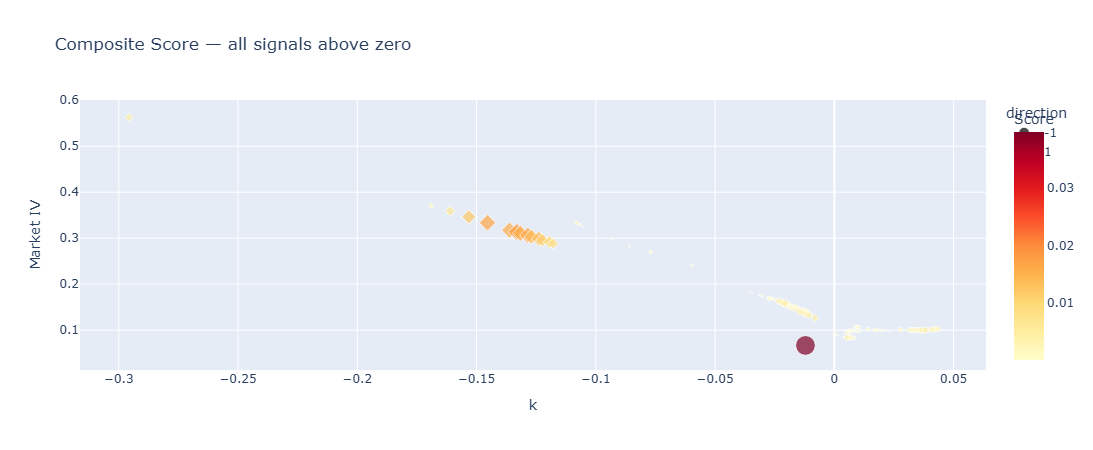

In [6]:
import plotly.express as px
fig = px.scatter(scored[scored['score']>0],
                 x='log_moneyness', y='iv', color='score',
                 color_continuous_scale='YlOrRd',
                 size='score', size_max=14,
                 symbol='direction',
                 hover_data=['strike','expiry','option_type','mu_gp','sigma_gp'],
                 title='Composite Score — all signals above zero',
                 labels={'log_moneyness':'k', 'iv':'Market IV', 'score':'Score'})
fig.update_layout(width=850, height=450)
fig.show()


In [7]:
scored.to_parquet("../data/scored_surface.parquet")
print("Saved → data/scored_surface.parquet")


Saved → data/scored_surface.parquet
